# Edge-level financial test: co-mentions and stock co-movement

This notebook tests whether the **edges** in the company co-mention graph have a financial meaning.

We test a more direct graph-finance hypothesis:

> Company pairs connected by a co-mention edge should have more correlated stock returns than company pairs with no edge.

Main output files:

- `edge_comovement_test_result.csv`
- `edge_pair_return_correlations.csv`
- `nonedge_pair_return_correlations.csv`
- `edge_vs_nonedge_return_corr.png`


## Methodology

The central financial quantity in this notebook is the **pairwise stock-return correlation**.

For a pair of tickers, for example `AAPL` and `MSFT`, the function `return_corr('AAPL', 'MSFT')` takes the two daily log-return series from `daily_returns_2017_2019.csv`, keeps only the dates where both stocks have valid returns, and computes their Pearson correlation:

```text
corr(AAPL daily returns, MSFT daily returns)
```

This correlation is a number between `-1` and `1`:

- values close to `1` mean the two stocks move together strongly;
- values close to `0` mean little linear co-movement;
- values below `0` mean they tend to move in opposite directions.

We only keep a pair if the two stocks overlap for at least `MIN_OVERLAP_DAYS` trading days, so that the correlation is not based on a tiny sample.

The statistical design is then simple:

1. Build the **edge group**: company pairs that are connected in the co-mention graph.
2. Build the **control group**: random company pairs from the same ticker universe that are not graph edges.
3. Compute one return correlation for every pair in both groups.
4. Apply the Fisher transform, `atanh(r)`, because raw correlations are bounded in `[-1, 1]` and Fisher-z correlations are better for mean-based tests.
5. Compare the two groups with a two-sample test.

The null hypothesis is:

```text
H0: co-mention edge pairs and random non-edge pairs have the same mean return correlation.
```

The alternative hypothesis is:

```text
H1: co-mention edge pairs have higher mean return correlation.
```

If the edge group has significantly higher correlations, we interpret this as evidence that the news co-mention graph captures real financial co-movement between firms.


## 1. Imports and paths

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

HERE = Path('.').resolve()

RANDOM_STATE = 42
MIN_OVERLAP_DAYS = 250
MAX_PAIRS = 5000

rng = np.random.default_rng(RANDOM_STATE)


## 2. Load graph, financial data, and return panel

In [2]:
edges = pd.read_csv(HERE / 'company_comention_edges.csv')
nodes = pd.read_csv(HERE / 'company_article_counts.csv')
fin = pd.read_csv(HERE / 'company_financials.csv')
ret = pd.read_csv(HERE / 'daily_returns_2017_2019.csv', index_col=0, parse_dates=True)

print(f'edges: {len(edges):,}')
print(f'financial rows: {len(fin):,}')
print(f'return panel: {ret.shape[0]:,} days x {ret.shape[1]:,} tickers')

fin.head()

edges: 9,092
financial rows: 727
return panel: 752 days x 724 tickers


,ticker,n_obs,vol_annualised,cum_return,mean_daily_ret,sharpe_proxy,company_id,company,cluster,industry_group,industries,weighted_degree,degree,degree_centrality,pagerank,betweenness,article_count,sector,sector_coarse
0,AA,752,0.409933,-0.259799,-0.000400,-0.245921,Q135325,Alcoa,9,Materials / Mining / Chemicals,Aluminium production; aluminium industry,18,11,0.009394,0.000581,0.000006,15,Materials / Mining / Chemicals,Materials / Mining / Chemicals
1,AAPL,752,0.247422,1.627399,0.001285,1.308335,Q312,Apple Inc.,0,Technology / Telecom,software development; digital distribution; so...,1126,234,0.199829,0.023396,0.433388,684,Technology / Telecom,Technology / Telecom
2,AB,752,0.216490,0.651029,0.000667,0.776119,Q4732268,AllianceBernstein,7,Finance,asset management,4,4,0.003416,0.000238,0.000000,5,Finance,Finance
3,ABBV,752,0.279450,0.613763,0.000636,0.573882,Q14662364,AbbVie,11,Healthcare,biotechnology; pharmaceutical industry,8,7,0.005978,0.000346,0.000000,5,Healthcare,Healthcare
4,ABT,752,0.191195,1.354455,0.001139,1.500848,Q306764,Abbott Laboratories,11,Healthcare,medical technology industry,23,19,0.016225,0.000958,0.000151,16,Healthcare,Healthcare


## 3. Convert graph edges into ticker pairs

The graph is stored with Wikidata company IDs. Financial returns are stored by ticker, so we map each edge `(company_id_A, company_id_B)` to `(ticker_A, ticker_B)`. We keep only pairs where both tickers have enough daily return observations.

In [3]:
id_to_ticker = dict(zip(fin['company_id'], fin['ticker']))
id_to_sector = dict(zip(fin['company_id'], fin['sector_coarse']))
id_to_name = dict(zip(nodes['company_id'], nodes['company']))
valid_tickers = set(ret.columns)

def valid_return_pair(a, b, min_days=MIN_OVERLAP_DAYS):
    pair = ret[[a, b]].dropna()
    return len(pair) >= min_days

edge_rows = []
for row in edges.itertuples(index=False):
    ticker_a = id_to_ticker.get(row.source)
    ticker_b = id_to_ticker.get(row.target)
    if not isinstance(ticker_a, str) or not isinstance(ticker_b, str):
        continue
    if ticker_a == ticker_b:
        continue
    if ticker_a not in valid_tickers or ticker_b not in valid_tickers:
        continue
    if not valid_return_pair(ticker_a, ticker_b):
        continue
    edge_rows.append({
        'source_id': row.source,
        'target_id': row.target,
        'source_name': getattr(row, 'source_name', id_to_name.get(row.source, row.source)),
        'target_name': getattr(row, 'target_name', id_to_name.get(row.target, row.target)),
        'ticker_a': ticker_a,
        'ticker_b': ticker_b,
        'weight': int(row.weight),
        'sector_a': id_to_sector.get(row.source),
        'sector_b': id_to_sector.get(row.target),
    })

edge_pairs = pd.DataFrame(edge_rows).drop_duplicates(['ticker_a', 'ticker_b']).reset_index(drop=True)
if len(edge_pairs) > MAX_PAIRS:
    edge_pairs = edge_pairs.sample(MAX_PAIRS, random_state=RANDOM_STATE).reset_index(drop=True)

print(f'usable co-mention edges with stock returns: {len(edge_pairs):,}')
edge_pairs.head(10)

usable co-mention edges with stock returns: 4,159


,source_id,target_id,source_name,target_name,ticker_a,ticker_b,weight,sector_a,sector_b
0,Q312,Q95,Apple Inc.,Google,AAPL,GOOGL,126,Technology / Telecom,Technology / Telecom
1,Q312,Q3884,Apple Inc.,Amazon,AAPL,AMZN,119,Technology / Telecom,Technology / Telecom
2,Q3884,Q95,Amazon,Google,AMZN,GOOGL,108,Technology / Telecom,Technology / Telecom
3,Q20800404,Q95,Alphabet Inc.,Google,GOOG,GOOGL,108,Technology / Telecom,Technology / Telecom
4,Q2283,Q312,Microsoft,Apple Inc.,MSFT,AAPL,88,Technology / Telecom,Technology / Telecom
5,Q2283,Q95,Microsoft,Google,MSFT,GOOGL,86,Technology / Telecom,Technology / Telecom
6,Q193326,Q334204,Goldman Sachs,Morgan Stanley,GS,MS,69,Finance,Finance
7,Q2283,Q3884,Microsoft,Amazon,MSFT,AMZN,66,Technology / Telecom,Technology / Telecom
8,Q219508,Q334204,Citigroup,Morgan Stanley,C,MS,63,Finance,Finance
9,Q3884,Q483551,Amazon,Walmart,AMZN,WMT,61,Technology / Telecom,Consumer / Retail / Food


## 4. Build a random non-edge baseline

For the control group, sample ticker pairs from the same ticker universe but exclude pairs that appear as graph edges. This gives a fairer comparison than sampling from all public companies, because both groups come from companies that actually appear in the graph.

In [4]:
def pair_key(a, b):
    return tuple(sorted((a, b)))

# Use every valid graph edge when excluding controls. This matters if we later sample edges.
all_edge_set = {pair_key(a, b) for a, b in zip(edge_pairs['ticker_a'], edge_pairs['ticker_b'])}
ticker_universe = sorted(set(edge_pairs['ticker_a']).union(edge_pairs['ticker_b']))

nonedge_rows = []
seen_nonedges = set()
tries = 0
max_tries = max(1000, len(edge_pairs) * 200)

while len(nonedge_rows) < len(edge_pairs) and tries < max_tries:
    ticker_a, ticker_b = rng.choice(ticker_universe, size=2, replace=False)
    key = pair_key(ticker_a, ticker_b)
    tries += 1

    if key in all_edge_set or key in seen_nonedges:
        continue
    if not valid_return_pair(ticker_a, ticker_b):
        continue

    seen_nonedges.add(key)
    nonedge_rows.append({'ticker_a': ticker_a, 'ticker_b': ticker_b})

nonedge_pairs = pd.DataFrame(nonedge_rows)
print(f'random non-edge control pairs: {len(nonedge_pairs):,}')
nonedge_pairs.head()


random non-edge control pairs: 4,159


,ticker_a,ticker_b
0,AXP,SAP
1,HUBG,HPE
2,PHM,AVA
3,AYI,LITE
4,QLYS,RRC


## 5. Compute pairwise return correlations

The financial variable is the Pearson correlation of daily log-returns over 2017-2019. For hypothesis testing we also compute the Fisher transform, `z = atanh(r)`, because raw correlations are bounded in `[-1, 1]` and therefore not ideal for a t-test.

In [5]:
def return_corr(ticker_a, ticker_b):
    pair = ret[[ticker_a, ticker_b]].dropna()
    if len(pair) < MIN_OVERLAP_DAYS:
        return np.nan
    return pair[ticker_a].corr(pair[ticker_b])

def add_correlations(df):
    out = df.copy()
    out['return_corr'] = [return_corr(a, b) for a, b in zip(out['ticker_a'], out['ticker_b'])]
    out = out.dropna(subset=['return_corr']).reset_index(drop=True)
    clipped = out['return_corr'].clip(-0.999999, 0.999999)
    out['fisher_z'] = np.arctanh(clipped)
    return out

edge_test = add_correlations(edge_pairs)
nonedge_test = add_correlations(nonedge_pairs)

summary = pd.DataFrame({
    'group': ['co-mention edge', 'random non-edge'],
    'n': [len(edge_test), len(nonedge_test)],
    'mean_corr': [edge_test['return_corr'].mean(), nonedge_test['return_corr'].mean()],
    'median_corr': [edge_test['return_corr'].median(), nonedge_test['return_corr'].median()],
    'std_corr': [edge_test['return_corr'].std(), nonedge_test['return_corr'].std()],
    'mean_fisher_z': [edge_test['fisher_z'].mean(), nonedge_test['fisher_z'].mean()],
})

summary

,group,n,mean_corr,median_corr,std_corr,mean_fisher_z
0,co-mention edge,4159,0.302468,0.280871,0.169357,0.327197
1,random non-edge,4159,0.195274,0.190780,0.127928,0.201784


## 6. Choose the statistical test

Null hypothesis: co-mentioned pairs and random non-edge pairs have the same mean Fisher-transformed return correlation.

Alternative hypothesis: co-mentioned pairs have a higher mean Fisher-transformed return correlation.

Test choice:

- If normality and equal variance look acceptable, use the standard Student two-sample t-test.
- If variances differ, use Welch's two-sample t-test.
- If normality is rejected but both samples are large, use Welch's t-test anyway; the comparison is on group means and the sample sizes are large.
- Mann-Whitney is reported only as a robustness check.


In [6]:
def shapiro_sample(x, max_n=5000):
    x = pd.Series(x).dropna().to_numpy()
    if len(x) > max_n:
        x = rng.choice(x, size=max_n, replace=False)
    return stats.shapiro(x)

def choose_two_sample_test(x, y, alternative='greater'):
    x = pd.Series(x).dropna().to_numpy()
    y = pd.Series(y).dropna().to_numpy()
    sw_x = shapiro_sample(x)
    sw_y = shapiro_sample(y)
    lev = stats.levene(x, y, center='median')
    large_sample = min(len(x), len(y)) >= 30
    normal_enough = (sw_x.pvalue >= 0.05) and (sw_y.pvalue >= 0.05)
    equal_var = lev.pvalue >= 0.05

    if normal_enough and equal_var:
        test_name = 'Student two-sample t-test'
        result = stats.ttest_ind(x, y, equal_var=True, alternative=alternative)
    elif normal_enough and not equal_var:
        test_name = "Welch two-sample t-test"
        result = stats.ttest_ind(x, y, equal_var=False, alternative=alternative)
    elif large_sample:
        test_name = "Welch two-sample t-test on Fisher-z correlations, using CLT"
        result = stats.ttest_ind(x, y, equal_var=False, alternative=alternative)
    else:
        test_name = 'Mann-Whitney U test fallback'
        result = stats.mannwhitneyu(x, y, alternative=alternative)

    sensitivity_mw = stats.mannwhitneyu(x, y, alternative=alternative)

    return {
        'chosen_test': test_name,
        'n_edge': len(x),
        'n_nonedge': len(y),
        'shapiro_edge_W': sw_x.statistic,
        'shapiro_edge_p': sw_x.pvalue,
        'shapiro_nonedge_W': sw_y.statistic,
        'shapiro_nonedge_p': sw_y.pvalue,
        'levene_stat': lev.statistic,
        'levene_p': lev.pvalue,
        'test_stat': result.statistic,
        'p_value': result.pvalue,
        'mw_sensitivity_U': sensitivity_mw.statistic,
        'mw_sensitivity_p': sensitivity_mw.pvalue,
    }

test_result = choose_two_sample_test(edge_test['fisher_z'], nonedge_test['fisher_z'])
pd.Series(test_result)

chosen_test          Welch two-sample t-test on Fisher-z correlatio...
n_edge                                                            4159
n_nonedge                                                         4159
shapiro_edge_W                                                0.911601
shapiro_edge_p                                                     0.0
shapiro_nonedge_W                                             0.984523
shapiro_nonedge_p                                                  0.0
levene_stat                                                 296.630598
levene_p                                                           0.0
test_stat                                                    31.908201
p_value                                                            0.0
mw_sensitivity_U                                            11905525.0
mw_sensitivity_p                                                   0.0
dtype: object

## 7. Visualise the effect

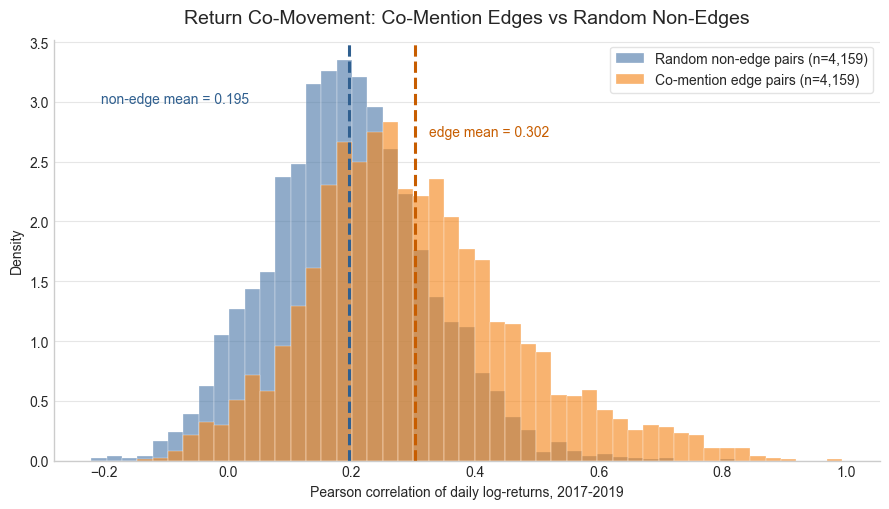

In [7]:
plt.style.use('seaborn-v0_8-whitegrid')

edge_corr = edge_test['return_corr']
nonedge_corr = nonedge_test['return_corr']
edge_mean = edge_corr.mean()
nonedge_mean = nonedge_corr.mean()

fig, ax = plt.subplots(figsize=(9, 5.2))

bins = np.linspace(
    min(edge_corr.min(), nonedge_corr.min()),
    max(edge_corr.max(), nonedge_corr.max()),
    50,
)

ax.hist(
    nonedge_corr,
    bins=bins,
    density=True,
    alpha=0.62,
    color='#4C78A8',
    edgecolor='white',
    linewidth=0.35,
    label=f'Random non-edge pairs (n={len(nonedge_corr):,})',
)
ax.hist(
    edge_corr,
    bins=bins,
    density=True,
    alpha=0.62,
    color='#F58518',
    edgecolor='white',
    linewidth=0.35,
    label=f'Co-mention edge pairs (n={len(edge_corr):,})',
)

ax.axvline(nonedge_mean, color='#2F5F8F', linestyle='--', linewidth=2.2)
ax.axvline(edge_mean, color='#C75D00', linestyle='--', linewidth=2.2)

ax.annotate(
    f'non-edge mean = {nonedge_mean:.3f}',
    xy=(nonedge_mean, ax.get_ylim()[1] * 0.86),
    xytext=(-72, 0),
    textcoords='offset points',
    color='#2F5F8F',
    fontsize=10,
    ha='right',
    va='center',
)
ax.annotate(
    f'edge mean = {edge_mean:.3f}',
    xy=(edge_mean, ax.get_ylim()[1] * 0.78),
    xytext=(10, 0),
    textcoords='offset points',
    color='#C75D00',
    fontsize=10,
    ha='left',
    va='center',
)

ax.set_title('Return Co-Movement: Co-Mention Edges vs Random Non-Edges', fontsize=14, pad=12)
ax.set_xlabel('Pearson correlation of daily log-returns, 2017-2019')
ax.set_ylabel('Density')
ax.legend(frameon=True, facecolor='white', edgecolor='#DDDDDD', loc='upper right')
ax.grid(axis='y', color='#E6E6E6')
ax.grid(axis='x', visible=False)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

plt.tight_layout()
plt.savefig(HERE / 'edge_vs_nonedge_return_corr.png', dpi=180, bbox_inches='tight')
plt.show()


## 8. Does edge weight matter?

A second financial test asks whether stronger co-mention edges correspond to stronger return co-movement.

Because edge weight is a very skewed count variable, the parametric version uses `log1p(weight)` and Fisher-z return correlation. Spearman rank correlation is reported as a robustness check.

Pearson on log(1+weight) vs Fisher-z correlation: r=0.293, p=2.4e-83
Spearman sensitivity check: rho=0.215, p=9.01e-45
OLS visual slope on log(1+weight): 0.085


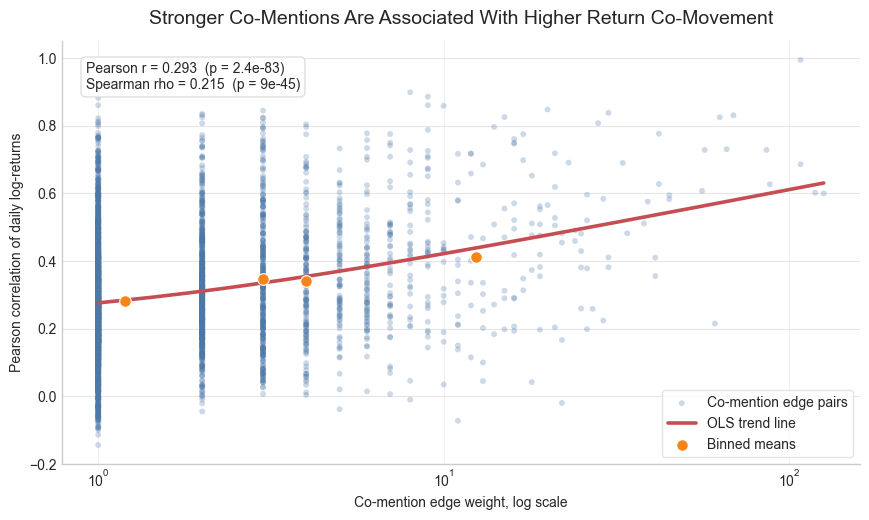

In [ ]:
edge_weight_test = edge_test.copy()
edge_weight_test['log_weight'] = np.log1p(edge_weight_test['weight'])

pearson_r, pearson_p = stats.pearsonr(edge_weight_test['log_weight'], edge_weight_test['fisher_z'])
spearman_rho, spearman_p = stats.spearmanr(edge_weight_test['weight'], edge_weight_test['return_corr'])

# Simple OLS line for the plot: return_corr = a + b * log(1 + weight).
# This is only a visual trend line; the statistical test above uses Fisher-z correlations.
slope, intercept = np.polyfit(edge_weight_test['log_weight'], edge_weight_test['return_corr'], deg=1)
x_line = np.linspace(edge_weight_test['weight'].min(), edge_weight_test['weight'].max(), 300)
y_line = intercept + slope * np.log1p(x_line)

print(f"Pearson on log(1+weight) vs Fisher-z correlation: r={pearson_r:.3f}, p={pearson_p:.3g}")
print(f"Spearman sensitivity check: rho={spearman_rho:.3f}, p={spearman_p:.3g}")
print(f"OLS visual slope on log(1+weight): {slope:.3f}")

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8.8, 5.3))

ax.scatter(
    edge_weight_test['weight'],
    edge_weight_test['return_corr'],
    alpha=0.28,
    s=18,
    color='#4C78A8',
    edgecolor='none',
    label='Co-mention edge pairs',
)

# Bin by edge weight quantiles and plot the average return correlation in each bin.
binned = edge_weight_test.copy()
binned['weight_bin'] = pd.qcut(binned['weight'], q=10, duplicates='drop')
bin_summary = (binned.groupby('weight_bin', observed=True)
    .agg(mean_weight=('weight', 'mean'), mean_corr=('return_corr', 'mean'), n=('return_corr', 'size'))
    .reset_index())

ax.plot(
    x_line,
    y_line,
    color='#C44E52',
    linewidth=2.6,
    label='OLS trend line',
)
ax.scatter(
    bin_summary['mean_weight'],
    bin_summary['mean_corr'],
    s=70,
    color='#F58518',
    edgecolor='white',
    linewidth=0.8,
    zorder=4,
    label='Binned means',
)

ax.set_xscale('log')
ax.set_xlabel('Co-mention edge weight, log scale')
ax.set_ylabel('Pearson correlation of daily log-returns')
ax.set_title('Stronger Co-Mentions Are Associated With Higher Return Co-Movement', fontsize=14, pad=12)

annotation = (
    f"Pearson r = {pearson_r:.3f}  (p = {pearson_p:.2g})\n"
    f"Spearman rho = {spearman_rho:.3f}  (p = {spearman_p:.2g})"
)
ax.text(
    0.03,
    0.95,
    annotation,
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=10,
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#DDDDDD', alpha=0.93),
)

ax.legend(frameon=True, facecolor='white', edgecolor='#DDDDDD', loc='lower right')
ax.grid(axis='y', color='#E6E6E6')
ax.grid(axis='x', color='#F0F0F0', which='major')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

plt.tight_layout()
plt.savefig(HERE / 'edge_weight_vs_return_corr.png', dpi=180, bbox_inches='tight')
plt.show()


## 9. Sector robustness check

Stock correlations are strongly sector-driven. This table separates co-mention edges that connect firms in the same coarse sector from those that connect different sectors.

In [9]:
edge_test['same_sector'] = edge_test['sector_a'].notna() & (edge_test['sector_a'] == edge_test['sector_b'])

sector_summary = (edge_test
    .groupby('same_sector')['return_corr']
    .agg(['count', 'mean', 'median', 'std'])
    .rename(index={False: 'cross-sector edge', True: 'same-sector edge'}))

sector_summary

,count,mean,median,std
same_sector,,,,
cross-sector edge,2830,0.262973,0.255475,0.140263
same-sector edge,1329,0.386571,0.370858,0.193623


## 10. Save outputs

In [11]:
edge_test.to_csv(HERE / 'edge_pair_return_correlations.csv', index=False)
nonedge_test.to_csv(HERE / 'nonedge_pair_return_correlations.csv', index=False)
pd.Series(test_result).to_csv(HERE / 'edge_comovement_test_result.csv')

edge_mean = edge_test['return_corr'].mean()
nonedge_mean = nonedge_test['return_corr'].mean()
edge_med = edge_test['return_corr'].median()
nonedge_med = nonedge_test['return_corr'].median()

## Interpretation

The edge-level test shows that the co-mention graph contains a clear financial signal. Co-mentioned company pairs have significantly higher stock-return co-movement than random non-edge pairs from the same ticker universe. Because normality and equal-variance assumptions are rejected, we use Welch's two-sample t-test on Fisher-z transformed correlations; with 4,159 pairs in each group, the p-value is effectively zero. The Mann-Whitney robustness check gives the same conclusion.

The edge-weight analysis strengthens this result. Among co-mentioned pairs, log co-mention weight is positively correlated with Fisher-z return correlation (Pearson r = 0.293, p = 2.4e-83), and the rank-based Spearman check is also positive and significant (rho = 0.215, p = 9.0e-45). Therefore, not only does the presence of a co-mention edge matter, but stronger co-mention ties correspond to stronger stock co-movement.

The sector robustness check confirms that part of the signal is sector-driven: same-sector edges have much higher average return correlation than cross-sector edges (0.387 vs 0.263). This is financially expected, since firms in the same sector share common risk factors. However, cross-sector co-mention edges still have substantial co-movement, which suggests that the graph is not merely rediscovering sectors. It also captures broader economic, supply-chain, competitor, platform, financing, or market-attention relationships across sectors.

Overall, the result supports the main claim that the news co-mention graph is not only a textual artifact. Its edges, and especially its weighted edges, encode real financial relationships between companies.